<a href="https://colab.research.google.com/github/BaderAlsulaimani/learn-git-with-pathy/blob/main/Employee_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAV Assignment #1

Course: AI3301 - Data Analytics and Visualization

Instructor: Muhammad Arif

Section: 2

Group Leader:
- Bader Alsulaimani

Group Members:
- Bader Alsulaimani (446004417)
- Yasser Albarqi (446004268)

Work Distribution:
- Bader: Dataset loading, data understanding, and data cleaning.
- Yasser: Exploratory data analysis (EDA), report writing, and documentation.

# Problem Definition

In this assignment we will analyze an employee dataset

The main goal is to understand the dataset, identify data quality issues, clean the data and perform exploratory data analysis (EDA)

In [ ]:
import pandas as pd

df = pd.read_csv("hr_employee_main.csv")
df.head()



df.isnull().sum()



,0
employee_id,0
department,0
job_role,0
hire_date,0
salary_raw,403
bonus_pct,498
performance_score,300
years_experience,404
education,204
gender,0


# Dataset Dimensions

In this section, the dimensions of the dataset are examined to determine the number of records and attributes available for analysis.

In [ ]:
df.shape

(10000, 16)

(10000, 16)

The dataset contains 10,000 records and 16 attributes. This indicates that the dataset is sufficiently large for data analysis and exploration.

# Data Types Inspection

The data types of all attributes are examined to understand the structure of the dataset and identify any columns that may require conversion during the cleaning process.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        10000 non-null  object 
 1   department         10000 non-null  object 
 2   job_role           10000 non-null  object 
 3   hire_date          10000 non-null  object 
 4   salary_raw         9597 non-null   object 
 5   bonus_pct          9502 non-null   float64
 6   performance_score  9700 non-null   float64
 7   years_experience   9596 non-null   float64
 8   education          9796 non-null   object 
 9   gender             10000 non-null  object 
 10  age                9799 non-null   float64
 11  city               10000 non-null  object 
 12  attrition          10000 non-null  object 
 13  satisfaction       9496 non-null   float64
 14  overtime_hours     9701 non-null   float64
 15  training_hours     10000 non-null  int64  
dtypes: float64(6), int64(1)

The dataset contains both numerical and categorical variables. Initial inspection revealed that some columns such as salary_raw and hire_date are stored as object data types and may require further processing during the data cleaning stage.

# Summary Statistics

Statistics were calculated for descriptive purposes in order to get an idea of how numerical variables are distributed and any potential outliers that exist.

In [ ]:
df.describe()


,bonus_pct,performance_score,years_experience,age,satisfaction,overtime_hours,training_hours
count,9502.000000,9700.000000,9596.000000,9799.000000,9496.000000,9701.000000,10000.000000
mean,10.105241,3.597113,14.533972,37.753648,5.500948,6.804453,20.031400
std,7.089982,7.784283,8.637304,9.942195,2.865090,19.267643,4.502271
min,0.000000,-1.000000,0.000000,4.000000,1.000000,-5.000000,4.000000
25%,5.000000,2.000000,7.000000,31.000000,3.000000,3.000000,17.000000
50%,10.000000,3.000000,14.000000,38.000000,6.000000,5.000000,20.000000
75%,15.000000,4.000000,22.000000,44.000000,8.000000,6.000000,23.000000
max,20.000000,99.000000,29.000000,84.000000,10.000000,200.000000,39.000000


There were some data quality problems identified from the descriptive statistics analysis.

For instance, some variables have some unrealistic values like age of 4 years old, performance values of -1 to 99, and overtime values of -5 to 200.

Such findings indicate the existence of outliers and data entry errors that will be considered during data cleaning.

# Data Wrangling and Cleaning

In this section, the dataset will be examined for missing values, duplicate records, inconsistent categories, and other data quality issues before analysis.

In [ ]:
df.isnull().sum()

,0
employee_id,0
department,0
job_role,0
hire_date,0
salary_raw,403
bonus_pct,498
performance_score,300
years_experience,404
education,204
gender,0


# Missing Values Analysis

The dataset has been analyzed for missing values along with calculating the missing values percentage in each column. This will help us decide how we need to clean the dataset.

In [ ]:
df.isnull().mean() * 100


,0
employee_id,0.00
department,0.00
job_role,0.00
hire_date,0.00
salary_raw,4.03
bonus_pct,4.98
performance_score,3.00
years_experience,4.04
education,2.04
gender,0.00


Many variables have missing values. The variables that had the largest proportion of missing values include satisfaction, bonus_pct, years_experience, and salary_raw. This is because the proportion of missing values is not very high and thus the variables can be cleaned up without deleting many rows from the data.

# Duplicate Records Analysis

The dataset was examined for duplicate records to determine whether repeated observations exist and could affect the analysis results.

In [ ]:
df.duplicated().sum()

np.int64(200)

This data set has 200 duplicated records. Duplicated records can influence the results of summary statistics and the analysis and need to be addressed while cleaning the data.

# Inconsistent Categories Analysis

Categorical variables were inspected to identify inconsistent labels and formatting issues. Different representations of the same category can lead to incorrect analysis results and misleading visualizations.

In [ ]:
df["department"].value_counts()


,count
department,
Human Resources,1046
Finance,1042
Engineering,1022
Sales,1006
HR,1001
Eng,997
SALES,983
Mktg,981
Marketing,965


In the "Department" column, there is inconsistency in the names of categories. Examples include: Sales written as Sales, SALES, and sales. Likewise, Human Resources is written as HR and Human Resources, while Engineering is written as Eng and Engineering.

This problem needs to be addressed while cleaning the data.

# Attrition Category Inspection

The attrition column was examined to identify inconsistencies in category labels that may affect analysis and visualization results.

In [ ]:
df["attrition"].unique()

array(['N', 'No', 'TRUE', 'FALSE', 'Yes', 'Y'], dtype=object)

In the attrition column, there are inconsistencies in naming for the same result. Some instances of attrition are named Yes, Y, and TRUE, whereas non-attributions are No, N, and FALSE.

This must be standardized in the cleaning process.

# Data Format Inspection

Several columns were inspected for formatting and data type issues that may affect analysis and data processing.

In [ ]:
df["salary_raw"].head(20)

,salary_raw
0,33750.0
1,70098.0
2,$72516.0
3,65373.0
4,$74479.0
5,59718.0
6,52906.0
7,25870.0
8,38613.0
9,52853.0


The salary_raw column has the salaries expressed in string format. The records contain a dollar sign ($) which leads to storing these values in an object data type rather than a numeric data type.

This needs to be fixed in the data cleaning process.

# Date Format Inspection

The hire_date column was inspected to identify formatting inconsistencies that may affect date-related analysis and calculations.

In [ ]:
df["hire_date"].head(20)


,hire_date
0,2027-02-13
1,2022-10-29
2,2014-09-28
3,2022-12-26
4,2022-05-19
5,2027-05-12
6,2011-07-31
7,2024-03-30
8,2027-06-04
9,2011-03-16


The hire_date column contains dates stored in different formats. Some records use the YYYY-MM-DD format, while others use the DD/MM/YYYY format.

These inconsistencies may affect date calculations and time-based analysis. Therefore, the date format should be standardized during data cleaning.

# Outlier Inspection

Descriptive statistics were reviewed to identify unusual or unrealistic values that may affect the quality of the analysis.

In [ ]:
df.describe()

,bonus_pct,performance_score,years_experience,age,satisfaction,overtime_hours,training_hours
count,9502.000000,9700.000000,9596.000000,9799.000000,9496.000000,9701.000000,10000.000000
mean,10.105241,3.597113,14.533972,37.753648,5.500948,6.804453,20.031400
std,7.089982,7.784283,8.637304,9.942195,2.865090,19.267643,4.502271
min,0.000000,-1.000000,0.000000,4.000000,1.000000,-5.000000,4.000000
25%,5.000000,2.000000,7.000000,31.000000,3.000000,3.000000,17.000000
50%,10.000000,3.000000,14.000000,38.000000,6.000000,5.000000,20.000000
75%,15.000000,4.000000,22.000000,44.000000,8.000000,6.000000,23.000000
max,20.000000,99.000000,29.000000,84.000000,10.000000,200.000000,39.000000


There were several data points that could be considered as outliers.

These data points include:
- Age as young as 4 years old.
- Score of performance from -1 to 99.
- Overtime from -5 to 200.

These numbers seem impossible and require investigation and handling.

In [ ]:
df[["salary_raw","bonus_pct","performance_score",
    "years_experience","education",
    "age","satisfaction","overtime_hours"]].dtypes

,0
salary_raw,object
bonus_pct,float64
performance_score,float64
years_experience,float64
education,object
age,float64
satisfaction,float64
overtime_hours,float64


In [ ]:
df["age"].median()


38.0

In [ ]:
df["education"].mode()

,education
0,Bachelor


# Missing Values Percentage

The percentage of missing values was calculated to evaluate the severity of missing data in each column.
``

In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)

,0
satisfaction,5.04
bonus_pct,4.98
years_experience,4.04
salary_raw,4.03
performance_score,3.00
overtime_hours,2.99
education,2.04
age,2.01
employee_id,0.00
department,0.00


The percentage of missing values is relatively low across all affected columns. Therefore, missing values can be handled through imputation instead of removing large portions of the dataset.

In [ ]:
df["age"] = df["age"].fillna(df["age"].median())

df["years_experience"] = df["years_experience"].fillna(df["years_experience"].median())

df["bonus_pct"] = df["bonus_pct"].fillna(df["bonus_pct"].median())

df["performance_score"] = df["performance_score"].fillna(df["performance_score"].median())

df["satisfaction"] = df["satisfaction"].fillna(df["satisfaction"].median())

df["overtime_hours"] = df["overtime_hours"].fillna(df["overtime_hours"].median())

df["education"] = df["education"].fillna(df["education"].mode()[0])

Missing values in numerical columns were replaced using the median to reduce the effect of outliers. Missing values in the education column were replaced using the mode because it is a categorical variable.

In [ ]:
df.duplicated().sum()

np.int64(200)

The dataset contains 200 duplicate records which may affect the analysis results.

In [ ]:
df = df.drop_duplicates()

Duplicate records were removed to improve data quality and avoid biased analysis results.

In [ ]:
df["department"] = df["department"].replace({
    "SALES": "Sales",
    "sales": "Sales",
    "HR": "Human Resources",
    "Eng": "Engineering",
    "Mktg": "Marketing"
})

In [ ]:
df["department"].value_counts()

,count
department,
Sales,2886
Human Resources,2001
Engineering,1981
Marketing,1911
Finance,1021


Department names were standardized to ensure consistency across categories.

In [ ]:
df["attrition"] = df["attrition"].replace({
    "Y": "Yes",
    "TRUE": "Yes",
    "N": "No",
    "FALSE": "No"
})

In [ ]:
df["attrition"].value_counts()

,count
attrition,
Yes,4932
No,4868


Attrition labels were standardized to ensure consistent representation of employee status.

# Outlier Detection

Potential outliers were investigated using descriptive statistics. Several unrealistic values were identified in age, performance_score, and overtime_hours.

In [ ]:
(df["age"] < 18).sum()

np.int64(200)

In [ ]:
(df["performance_score"] < 0).sum()

np.int64(34)

In [ ]:
(df["performance_score"] > 5).sum()

np.int64(61)

In [ ]:
(df["overtime_hours"] < 0).sum()

np.int64(98)

Several unrealistic values were detected, including employee ages below 18 years, negative performance scores, performance scores greater than 5, and negative overtime hours.

In [ ]:
df.loc[df["age"] < 18, "age"] = df["age"].median()

In [ ]:
df.loc[df["performance_score"] < 0, "performance_score"] = df["performance_score"].median()

In [ ]:
df.loc[df["performance_score"] > 5, "performance_score"] = df["performance_score"].median()


In [ ]:
df.loc[df["overtime_hours"] < 0, "overtime_hours"] = df["overtime_hours"].median()

Unrealistic values were replaced using the median of the corresponding variable to reduce the impact of data entry errors while preserving the dataset size.

# Data Format Standardization

Columns with formatting issues were standardized to ensure they can be used correctly during the analysis stage.

In [ ]:
df["salary_raw"] = pd.to_numeric(df["salary_raw"], errors="coerce")

In [ ]:
df["salary_raw"].dtype

dtype('float64')

The salary column was converted from text format to numeric format after removing currency symbols.

In [ ]:
df["hire_date"] = pd.to_datetime(
    df["hire_date"],
    errors="coerce",
    dayfirst=True
)

/tmp/ipykernel_3743/3423729635.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["hire_date"] = pd.to_datetime(


In [ ]:
df["hire_date"].dtype

dtype('<M8[ns]')

The hire_date column was converted to datetime format to support date-based analysis.

# Salary Distribution

A histogram was created to examine the distribution of employee salaries and identify the overall salary pattern in the dataset.

In [ ]:
df["salary_raw"].isnull().sum()

np.int64(2316)

In [ ]:
df["salary_raw"].median()

60177.5

In [ ]:
df["salary_raw"] = df["salary_raw"].fillna(df["salary_raw"].median())

In [ ]:
df["salary_raw"].isnull().sum()


np.int64(0)

In [ ]:
df.isnull().sum()

,0
employee_id,0
department,0
job_role,0
hire_date,494
salary_raw,0
bonus_pct,0
performance_score,0
years_experience,0
education,0
gender,0


In [ ]:
df = df.dropna(subset=["hire_date"])

Invalid and missing date values in the hire_date column were removed because a valid hiring date is required for any date-based analysis.

In [ ]:
df.shape

(9306, 16)

After removing duplicate records and invalid dates, the dataset contains 9,306 records and 16 attributes. The cleaned dataset is now ready for exploratory data analysis.

# Exploratory Data Analysis (EDA)

The cleaned dataset was analyzed using visualizations to explore distributions and relationships among variables.


# Salary Distribution

A histogram was created to examine the distribution of employee salaries and identify the overall salary pattern in the dataset.

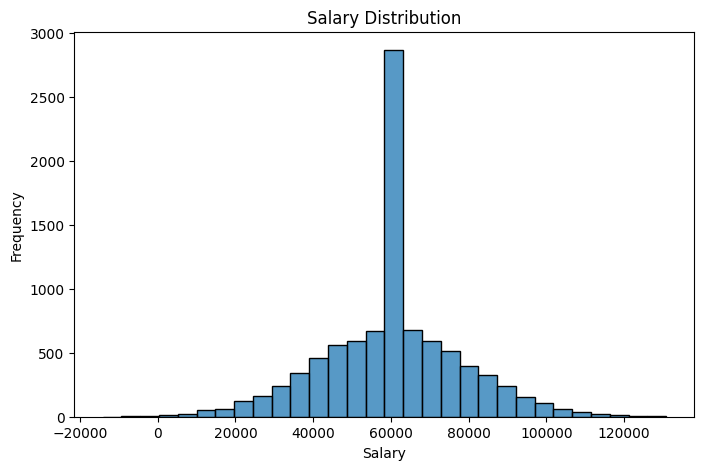

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["salary_raw"], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

The salary distribution appears approximately bell-shaped, with most employees earning salaries around 60,000.

A large concentration of observations is found near the center of the distribution, while fewer employees are located at very low or very high salary levels.

The distribution indicates that most salary values are clustered around the average salary range.

# Salary Outliers

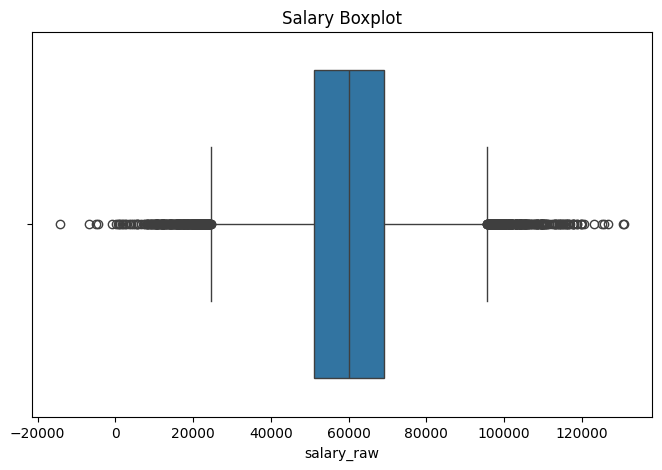

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["salary_raw"])
plt.title("Salary Boxplot")
plt.show()

The salary boxplot indicates the presence of several outliers on both the lower and upper ends of the salary distribution. However, these values may represent legitimate salary differences among employees rather than data errors.

# Age Distribution

The age distribution was examined to understand the demographic characteristics of employees.

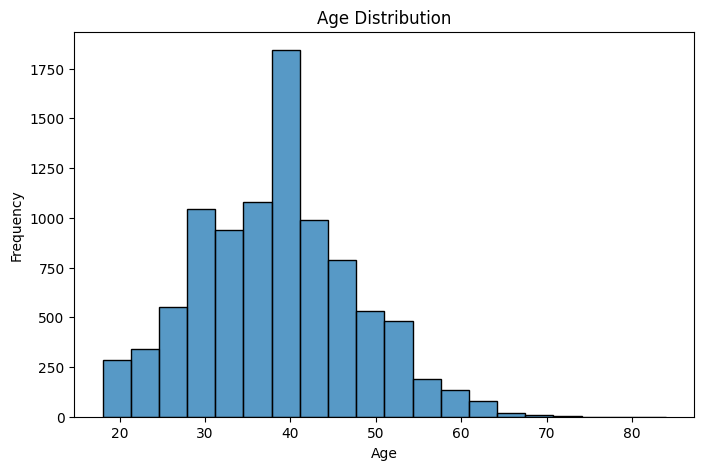

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The age distribution shows that most employees are concentrated between 30 and 45 years of age, with the highest frequency around 38 to 40 years.

The distribution appears relatively balanced and reflects a typical working-age population. The number of employees decreases gradually at higher age ranges.

# Relationship Between Salary and Experience

A scatter plot was created to investigate the relationship between years of experience and employee salaries.

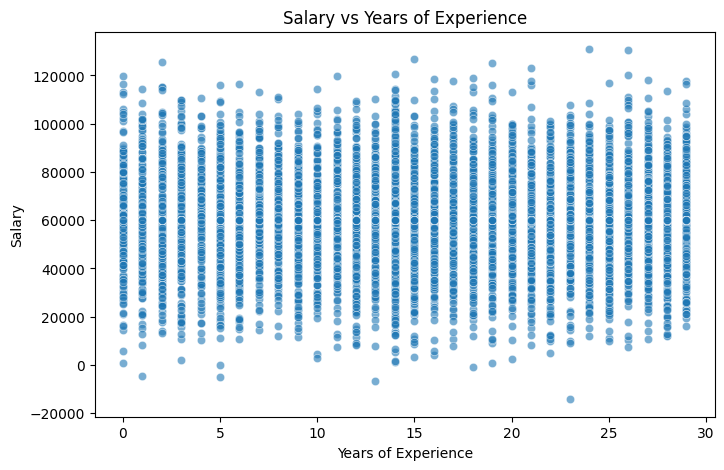

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary_raw",
    alpha=0.6
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

The scatter plot does not show a strong visible relationship between years of experience and salary. Salary values appear widely distributed across different experience levels, suggesting that additional factors may influence employee salaries.

In [ ]:
df[["salary_raw", "years_experience"]].corr()

,salary_raw,years_experience
salary_raw,1.000000,-0.009569
years_experience,-0.009569,1.000000


In [ ]:
df["salary_raw"].corr(df["years_experience"])

np.float64(-0.009568601844031204)

There is no significant relationship between years of experience and salary in this dataset. The correlation coefficient is approximately -0.01, indicating a very weak negative relationship.

# Correlation Heatmap

A correlation heatmap was generated to examine relationships among numerical variables in the dataset.

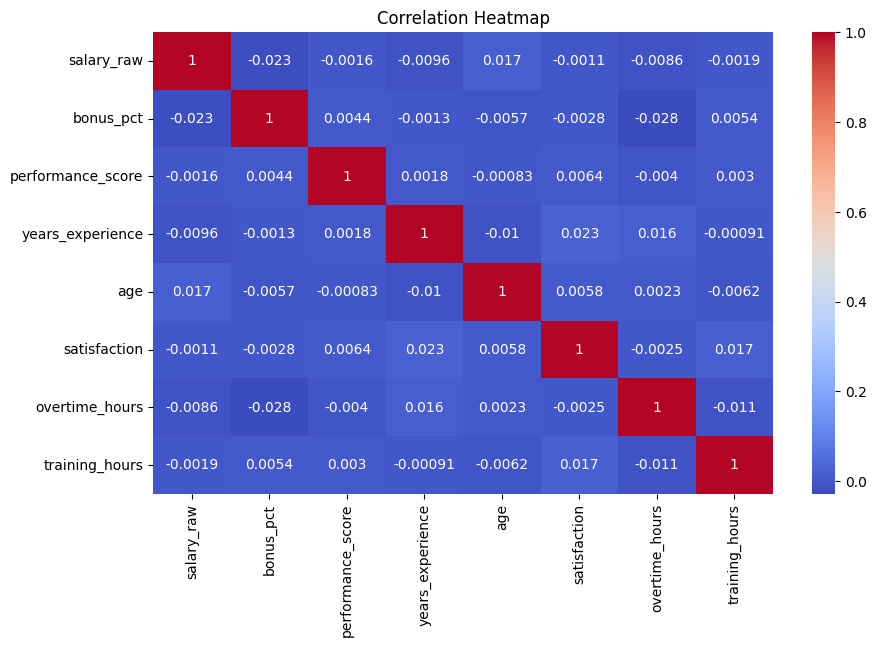

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows very weak relationships among the numerical variables in the dataset.

Most correlation coefficients are close to zero, indicating that no strong linear relationships exist between the examined variables.

For example, the correlation between salary and years of experience is approximately -0.01, suggesting virtually no linear relationship between these two variables in the dataset.

# Conclusion

The employee dataset was successfully examined, cleaned, and analyzed.

Several data quality issues were identified, including missing values, duplicate records, inconsistent category labels, mixed date formats, and unrealistic values. These issues were addressed through data cleaning and preprocessing techniques.

Exploratory Data Analysis (EDA) was performed using histograms, boxplots, scatter plots, and a correlation heatmap.

The analysis showed that employee salaries and ages follow reasonable distributions after cleaning. However, the correlation analysis revealed that the numerical variables in the dataset have very weak relationships with one another.

The cleaned dataset is now suitable for further analysis and visualization.

In [ ]:
df.shape

(9306, 16)